<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/GoingDeeper/Gd08/KoChatGPT_UPGRADE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KoChatGPT

## 노드 선택지를 참고하여 코드 구성함.

노드에서 알려준 선택지들 중에서 선택하여 이렇게 코드를 구성하였다.

- **데이터셋 정제**: 너무 짧거나 긴 답변, 중복, 이상한 문자 섞인 거 지우고, 줄어든 만큼 augmentation으로 다시 채웠다.
- **디코딩 하이퍼파라미터 서치**: greedy / beam / top-k / top-p 다 돌려보고 비교했는데,greedy가 제일 나았다.
- **정량적 메트릭 도입**: 주관적으로만 보던 걸 BLEU, ROUGE-L, RM reward로 같이 비교했다.
- **프롬프트 템플릿 서치**: 학습 포맷 / 명시적 지시문 / few-shot 세 가지로 비교해봤다.
- **더 큰 모델로 교체**: kogpt2 대신 ko-gpt-trinity-1.2B로 바꿔서 해봤다.
- **LoRA 적용**: 1.2B는 다 학습시키기엔 커서 LoRA로 가볍게 학습시켰다.
- **RM 데이터 일반화 개선**: 원래 앞 1,000개만 순서대로 쓰던 걸 셔플하고 전체의 80%를 쓰도록 고쳤다.


## 수정한 부분

**1차**
- 평가 데이터 누출: train/valid/test를 질문 단위로 미리 나누고, 모든 학습은 train만 쓰게 고침
- 한국어 ROUGE 계산 오류: 공백 기준 토크나이저 적용
- 조사 변형 augmentation 문법 깨짐 ("저는"→"저은"): 해당 규칙 제거
- 생성 결과 자르는 방식: 문자열 길이 대신 토큰 개수로 자르게 수정
- top-p/top-k 동시 적용 문제: top_k 명시적으로 끔
- 결론 숫자가 실제 출력과 불일치: 재실행 후 실제 숫자로 재작성

**2차**
- 종결어미 augmentation 문법 깨짐 ("좋습니다"→"좋어요"): 모음조화 규칙(ㅏ/ㅗ→아요, 그 외→어요) 적용
- 정제 효과와 증강 효과가 안 구분됨: 정제만 한 모델도 따로 학습해서 비교 추가
- RM 데이터 누출 (페어 단위로 섞어서 80:20 분리): 질문 단위로 먼저 나눈 뒤 페어 생성
- RM 채점 형식이 학습 형식과 다름 (학습은 prompt+답변, 채점은 답변만): 채점도 prompt+답변으로 통일
- RM 적용 전후 비교 없음: 답변 4개 샘플링 후 RM이 고른 것 vs 첫 번째 답변 비교(best-of-4) 추가

## Flow

```
데이터 다운로드 (KoChatGPT repo clone)
  │
라이브러리 설치 + Colab 호환 패치
  │
라이브러리 불러오기 / 공통 유틸 (seed 고정, device)
  │
하이퍼파라미터 CONFIG 정리
  │
SFT 학습 (원본 데이터)
  ├─ SFT_dataset 정의 → 데이터 로딩
  └─ trainer.train() → output_1_SFT 저장
  │
RM 학습
  ├─ ranking 데이터 → chosen/rejected 페어 구성
  └─ RewardModelTrainer.fit() → output_2_RM 저장
  │
질문 단위로 train / valid / test 분리 (누출 방지)
  │
프로젝트 구현: 데이터셋 정제
  ├─ EDA (도메인·문체·길이분포·노이즈)
  ├─ clean_sft_data() : 정제 (train에만 적용)
  └─ 종결어미 변형 / 동의어 치환 : 크기 유지 augmentation (2가지 기법 순환, 조사 변형은 문법 깨져서 제외)
  │
정제만 한 데이터 / 정제+증강 데이터로 각각 SFT 재학습
  │
디코딩 하이퍼파라미터 서치 (greedy / beam / top-k / top-p)
  │
프롬프트 템플릿 서치 (학습 포맷 / 명시적 지시문 / few-shot 비교)
  │
정량 비교 (Base vs SFT 정제전 vs SFT 정제만 vs SFT 정제+증강) — decoding/프롬프트는 valid로 고르고 test로 비교
  └─ generate_texts() → BLEU / ROUGE-L → 그래프
  │
RM 정량·정성 분석
  ├─ score_with_rm() → reward 평균/분포 그래프 (RM 학습 때처럼 prompt+answer로 채점)
  └─ 정성 샘플 직접 비교
  │
RM 적용 전후 비교 (best-of-4)
  └─ 같은 프롬프트로 답변 4개 샘플링 → 첫 번째 답변 vs RM이 고른 답변 비교
  │
(추가 실험) Foundation Model 교체 — ko-gpt-trinity-1.2B (LoRA)
  ├─ LoRA 적용 (c_attn에 저랭크 어댑터, 원본 가중치 동결) → 학습 파라미터 대폭 축소
  ├─ OOM 방지 training argument 탐색 (batch size / gradient accumulation / checkpointing)
  ├─ 같은 SFT 데이터로 재학습 → output_1_SFT_large 저장
  └─ 기존 4개 모델과 BLEU/ROUGE/RM reward 비교
  │
결과 분석 (정량적 / 정성적 해석 작성)
```

## 데이터 다운로드

In [1]:
!git clone https://github.com/airobotlab/KoChatGPT
!cp -r /content/KoChatGPT/colossalai_ChatGPT_230319/chatgpt /content/chatgpt

Cloning into 'KoChatGPT'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 57.72 MiB | 31.30 MiB/s, done.
Resolving deltas: 100% (123/123), done.


## 라이브러리 설치

In [2]:
!pip install datasets loralib trl evaluate rouge_score sacrebleu accelerate peft -q
# torchao 버전 때문에 에러나서 그냥 지웠다
!pip uninstall -y torchao -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 20.3 MB/s eta 0:00:00


## Colab 호환 패치

colab에서 계속 에러나길래 두 개 고쳤다.

In [3]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치')

[colab-compat] torch.load weights_only=False 패치


In [4]:
import os

modifications = [
    {
        "file": "/content/chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = True  # ColossalAIStrategy를 안 쓰니 이 분기는 항상 True"},
        ],
    },
    {
        "file": "/content/chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "/content/chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "/content/chatgpt/trainer/base.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "/content/chatgpt/trainer/rm.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

✅ 수정 완료: /content/chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: /content/chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: /content/chatgpt/dataset/reward_dataset.py
✅ 수정 완료: /content/chatgpt/trainer/base.py
✅ 수정 완료: /content/chatgpt/trainer/rm.py


## 라이브러리 불러오기 / 공통 유틸

In [5]:
import os, json, re, random, copy, logging
from collections import Counter
from dataclasses import dataclass
from typing import Optional, Dict, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import evaluate

try:
    !apt -qq -y install fonts-nanum > /dev/null 2>&1
    for font_file in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
        fm.fontManager.addfont(font_file)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception as e:
    print('[한글 폰트 설정 실패, 기본 폰트로 진행]', e)

import torch
import torch.nn as nn
from torch.utils.data import Dataset

import transformers
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM, AutoTokenizer
from transformers import set_seed as hf_set_seed
from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.rm import RewardModelTrainer

from peft import LoraConfig, get_peft_model, PeftModel, TaskType

SEED = 42

def set_all_seeds(seed=SEED):
    """random / numpy / torch / transformers 시드를 한 번에 고정"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    hf_set_seed(seed)

set_all_seeds()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device} | torch: {torch.__version__} | transformers: {transformers.__version__}")

device: cuda | torch: 2.11.0+cu128 | transformers: 5.16.1


## 하이퍼파라미터 정리

In [6]:
CONFIG = {
    "SEED": SEED,

    # SFT (원본 학습 + 정제 데이터 재학습 공통)
    "NUM_TRAIN_EPOCHS": 3,
    "TRAIN_BATCH_SIZE": 8,
    "EVAL_BATCH_SIZE": 8,
    "LEARNING_RATE": 5e-5,
    "WARMUP_STEPS": 5,

    # RM
    "RM_LEARNING_RATE": 5e-5,
    "RM_BATCH_SIZE": 4,
    "RM_MAX_EPOCHS": 2,

    # 데이터 정제 기준
    "MIN_COMPLETION_LEN": 5,
    "MAX_COMPLETION_LEN": 300,
    "NOISY_CHAR_RATIO": 0.1,

    # 평가
    "EVAL_SIZE": 100,
    "MAX_NEW_TOKENS": 64,

    # foundation model 교체 (1.2B, 추가 실험)
    "LARGE_MODEL_NAME": "skt/ko-gpt-trinity-1.2B-v0.5",
    "LARGE_EPOCHS": 3,
    "LARGE_LR": 1e-4,   # LoRA는 학습 대상이 작아서 풀 파인튜닝보다 조금 높은 lr을 씀

    # LoRA (경량화 파인튜닝)
    "LORA_R": 8,
    "LORA_ALPHA": 16,
    "LORA_DROPOUT": 0.05,
    "LORA_TARGET_MODULES": ["c_attn"],  # GPT2 계열 아키텍처의 QKV projection
}
CONFIG

{'SEED': 42,
 'NUM_TRAIN_EPOCHS': 3,
 'TRAIN_BATCH_SIZE': 8,
 'EVAL_BATCH_SIZE': 8,
 'LEARNING_RATE': 5e-05,
 'WARMUP_STEPS': 5,
 'RM_LEARNING_RATE': 5e-05,
 'RM_BATCH_SIZE': 4,
 'RM_MAX_EPOCHS': 2,
 'MIN_COMPLETION_LEN': 5,
 'MAX_COMPLETION_LEN': 300,
 'NOISY_CHAR_RATIO': 0.1,
 'EVAL_SIZE': 100,
 'MAX_NEW_TOKENS': 64,
 'LARGE_MODEL_NAME': 'skt/ko-gpt-trinity-1.2B-v0.5',
 'LARGE_EPOCHS': 3,
 'LARGE_LR': 0.0001,
 'LORA_R': 8,
 'LORA_ALPHA': 16,
 'LORA_DROPOUT': 0.05,
 'LORA_TARGET_MODULES': ['c_attn']}

## 데이터 로드 및 질문 단위 분리

평가할 때 학습 때 본 질문이 다시 나오면 안 되니까, 맨 처음에 질문 단위로 train/valid/test를 나눠둔다. 정제도 train에만 적용하고, decoding·프롬프트 설정은 valid로 고르고, 최종 비교는 test로 한다.

In [7]:
def load_jsonl_dict(path):
    with open(path, "r", encoding='utf-8-sig') as f:
        return json.load(f)

sft_data = load_jsonl_dict('/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl')
rm_data  = load_jsonl_dict('/content/KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl')
ppo_data = load_jsonl_dict('/content/KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl')
print(f"SFT: {len(sft_data)}개, RM: {len(rm_data)}개, PPO: {len(ppo_data)}개")


def question_key(text):
    """공백 차이만 정규화한, 같은 질문인지 판단하는 기준"""
    return ' '.join(text.split())


usable_sft = [d for d in sft_data if d.get('prompt', '').strip() and d.get('completion', '').strip()]
keys = sorted({question_key(d['prompt']) for d in usable_sft})

random.seed(CONFIG["SEED"])
random.shuffle(keys)

N_TEST, N_VALID = 100, 100
test_keys  = set(keys[:N_TEST])
valid_keys = set(keys[N_TEST:N_TEST + N_VALID])
train_keys = set(keys[N_TEST + N_VALID:])


def first_per_question(rows, selected_keys):
    """같은 질문이 여러 번 있어도 평가에는 한 번만 쓴다"""
    result, seen = [], set()
    for d in rows:
        k = question_key(d['prompt'])
        if k in selected_keys and k not in seen:
            result.append(d)
            seen.add(k)
    return result


train_raw  = [d for d in usable_sft if question_key(d['prompt']) in train_keys]
valid_rows = first_per_question(usable_sft, valid_keys)
test_rows  = first_per_question(usable_sft, test_keys)

assert not (train_keys & valid_keys or train_keys & test_keys or valid_keys & test_keys)
print(f"train: {len(train_raw)}개, valid: {len(valid_rows)}개, test: {len(test_rows)}개")

# 원본 SFT 학습에 쓸 train 전용 파일 저장 (평가 질문이 안 섞이게)
train_raw_path = '/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_train.jsonl'
with open(train_raw_path, 'w', encoding='utf-8') as f:
    json.dump(train_raw, f, ensure_ascii=False)


SFT: 12000개, RM: 10220개, PPO: 12000개
train: 11795개, valid: 100개, test: 100개


## SFT 학습

In [8]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  513MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

TokenizersBackend(name_or_path='skt/kogpt2-base-v2', vocab_size=51200, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '</s>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<usr>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<sys>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	7: AddedT

In [9]:
class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [10]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

In [11]:
train_dataset = SFT_dataset(data_path_1_SFT=train_raw_path, tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914,   382, 37767, 13753,  8263,  7166,   739,  8352,  7659,
         9594, 25585, 13600,  8022,  9378, 11532,  9887, 11218,  9111, 16691,
        10351, 10561,  9128, 20479,  8091,  9065,  9446,  9036, 28420, 26521,
        10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209, 37194, 10351,
         9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188, 13362,  9036,
        15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806, 13480, 11342,
        17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592, 10751, 11814,
         8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -10

In [12]:
training_args = transformers.TrainingArguments(
    output_dir="/content/test",
    num_train_epochs=CONFIG["NUM_TRAIN_EPOCHS"],
    per_device_train_batch_size=CONFIG["TRAIN_BATCH_SIZE"],
    per_device_eval_batch_size=CONFIG["EVAL_BATCH_SIZE"],
    learning_rate=CONFIG["LEARNING_RATE"],
    warmup_steps=CONFIG["WARMUP_STEPS"],
    seed=CONFIG["SEED"],
    prediction_loss_only=True,
    fp16=True,
    )
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

In [13]:
trainer.train()
model.save_pretrained('/content/output_1_SFT')

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
500,2.986807
1000,2.861437
1500,2.779397
2000,2.250680
2500,2.260722
3000,2.194313
3500,1.828088
4000,1.841999


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
torch.cuda.empty_cache()

## RM 학습

In [15]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained


    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

In [16]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
with open('/content/KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

# SFT valid/test에 쓴 질문은 RM 학습에서 빼서, SFT 평가와 안 겹치게 한다
list_data_dict = [d for d in list_data_dict if question_key(d['prompt']) not in (valid_keys | test_keys)]


def build_ranking_pairs(rows):
    """한 질문에 나온 completion 3개를 chosen/rejected 페어 3개로 바꾼다"""
    total = []
    for tmp in rows:
        for i, j in [(0, 1), (0, 2), (1, 2)]:
            data = {'prompt': tmp['prompt']}
            if tmp['ranking'][i] < tmp['ranking'][j]:
                data['chosen'], data['rejected'] = tmp[f'completion_{i}'], tmp[f'completion_{j}']
            else:
                data['chosen'], data['rejected'] = tmp[f'completion_{j}'], tmp[f'completion_{i}']
            total.append(data)
    return total


print('RM 학습 후보 질문 수: %d' % len(list_data_dict))
print('페어 예시:', build_ranking_pairs(list_data_dict[:1]))

RM 학습 후보 질문 수: 10047
페어 예시: [{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?', 'chosen': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.', 'rejected': 'Allow me to answer your question. I know that you are curious about me.'}, {'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?', 'chosen': '라이언에게 말했다.', 'rejected': 'Allow me to answer your question. I know that you are curious about me.'}, {'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?', 'chosen': '라이언에게 말했다.', 'rejected': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.'}]


In [18]:
# 페어를 만들고 나서 섞으면 같은 질문에서 나온 페어가 train/eval 양쪽에 들어갈 수 있어서, 질문 단위로 먼저 나눈 다음에 각각 페어를 만든다
rm_keys = sorted({question_key(d['prompt']) for d in list_data_dict})
random.seed(CONFIG["SEED"])
random.shuffle(rm_keys)

rm_split_idx = int(len(rm_keys) * 0.8)
rm_train_keys = set(rm_keys[:rm_split_idx])
rm_valid_keys = set(rm_keys[rm_split_idx:])
assert not (rm_train_keys & rm_valid_keys)

rm_train_rows = [d for d in list_data_dict if question_key(d['prompt']) in rm_train_keys]
rm_valid_rows = [d for d in list_data_dict if question_key(d['prompt']) in rm_valid_keys]

train_data = build_ranking_pairs(rm_train_rows)
eval_data  = build_ranking_pairs(rm_valid_rows)

print(len(train_data))
print(len(eval_data))

train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

24099
6042


  0%|          | 0/24099 [00:00<?, ?it/s]

  0%|          | 0/6042 [00:00<?, ?it/s]

In [19]:
trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=CONFIG["RM_LEARNING_RATE"]),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=CONFIG["RM_BATCH_SIZE"],
                             max_epochs=CONFIG["RM_MAX_EPOCHS"])

In [20]:
trainer.fit(use_lora=0)

model.save_pretrained('/content/output_2_RM')
# save_pretrained는 backbone(GPT2Model)만 저장하고 value_head는 안 남기길래 따로 저장한다
torch.save(model.value_head.state_dict(), '/content/output_2_RM/value_head.pt')

Train epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/6025 [00:00<?, ?it/s]

Train step of epoch 1:   0%|          | 0/6025 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
torch.cuda.empty_cache()

### EDA — 도메인·문체·길이분포·노이즈 확인

#### 함수로 만들기 전에, 샘플 하나로 먼저 확인

In [22]:
sample = sft_data[0]
print("prompt:", sample['prompt'])
print("completion:", sample['completion'])

formal_endings = ('습니다.', '합니다.', '입니다.', '됩니다.')
informal_endings = ('해요.', '이에요.', '어요.', '아요.', '돼요.')
print("격식체 여부:", sample['completion'].strip().endswith(formal_endings))
print("비격식체 여부:", sample['completion'].strip().endswith(informal_endings))

sample_words = re.findall(r'[가-힣]{2,}', sample['completion'])
print("추출된 단어:", sample_words)

prompt: 불고기용 고기 한우에요?
completion: '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
격식체 여부: False
비격식체 여부: False
추출된 단어: ['저는', '인공지능', '챗봇이며', '직접적으로', '식품에', '관한', '정보를', '가지고', '있지', '않습니다', '하지만', '일반적으로', '불고기용', '고기는', '한우', '쇠고기', '돼지고기', '다양한', '종류의', '고기를', '사용합니다', '하지만', '한우는', '대표적인', '고급', '육류로', '알려져', '있기', '때문에', '한우를', '사용하는', '경우도', '많습니다', '알러지나', '개별', '건강', '상태에', '따라', '다를', '있으니', '충분한', '정보', '수집', '후에', '선택해', '주시기', '바랍니다']


[SFT] 개수=12000, prompt 평균 길이=22.2 (min=0, max=295)
       답변 평균 길이=144.1, 중복prompt=54, 5자미만=7, 300자초과=925
[SFT] 문체 - 격식체:8837 (73.6%) 비격식체:41 (0.3%) 기타:3122
[SFT] 도메인(상위 빈출 단어 10개): [('것이', 3194), ('저는', 2994), ('없습니다', 2395), ('하지만', 2129), ('대한', 2056), ('때문에', 1914), ('있는', 1850), ('정보를', 1761), ('제가', 1750), ('따라서', 1541)]


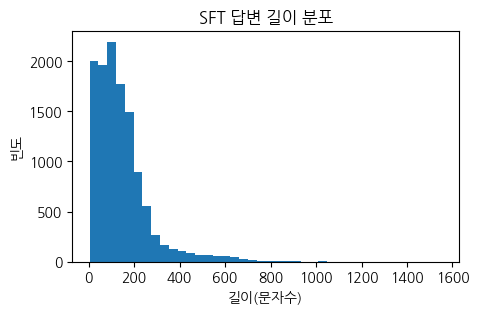


[RM] 개수=10220, prompt 평균 길이=22.2 (min=0, max=295)
       답변 평균 길이=117.5, 중복prompt=39, 5자미만=122, 300자초과=527
[RM] 문체 - 격식체:4602 (45.0%) 비격식체:45 (0.4%) 기타:5573
[RM] 도메인(상위 빈출 단어 10개): [('국가', 2369), ('것이', 1568), ('국내', 1320), ('것을', 1021), ('개인', 1016), ('있는', 881), ('저는', 880), ('그런데', 875), ('없습니다', 825), ('또한', 811)]


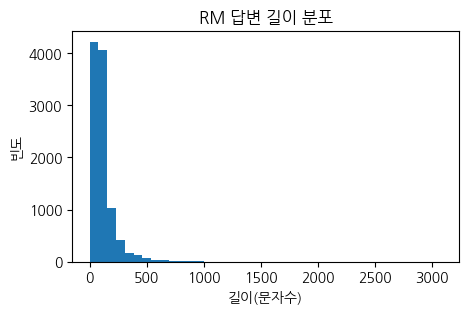


[PPO] 개수=12000, prompt 평균 길이=22.2 (min=0, max=295)



In [23]:
KOREAN_STOPWORDS = {
    '이', '그', '저', '것', '수', '등', '및', '을', '를', '은', '는', '이런', '그런', '저런',
    '의', '에', '에서', '으로', '로', '와', '과', '도', '만', '게', '거', '좀', '잘', '더', '안', '못', '있습니다', '합니다',
}

def analyze_style_and_domain(data, name, completion_key='completion'):
    """문체(격식체/비격식체 비율)와 도메인(상위 빈출 단어)을 간단히 분석합니다."""
    texts = [d[completion_key] for d in data if completion_key in d]
    if not texts:
        return

    formal_endings = ('습니다.', '합니다.', '입니다.', '됩니다.')
    informal_endings = ('해요.', '이에요.', '어요.', '아요.', '돼요.')
    formal_cnt = sum(1 for t in texts if t.strip().endswith(formal_endings))
    informal_cnt = sum(1 for t in texts if t.strip().endswith(informal_endings))
    other_cnt = len(texts) - formal_cnt - informal_cnt
    print(f"[{name}] 문체 - 격식체:{formal_cnt} ({formal_cnt/len(texts)*100:.1f}%) "
          f"비격식체:{informal_cnt} ({informal_cnt/len(texts)*100:.1f}%) 기타:{other_cnt}")

    words = []
    for t in texts:
        words.extend(re.findall(r'[가-힣]{2,}', t))
    words = [w for w in words if w not in KOREAN_STOPWORDS]
    top_words = Counter(words).most_common(10)
    print(f"[{name}] 도메인(상위 빈출 단어 10개): {top_words}")


def eda_report(data, name, completion_key='completion'):
    lengths_p = [len(d['prompt']) for d in data]
    print(f"[{name}] 개수={len(data)}, prompt 평균 길이={np.mean(lengths_p):.1f}"
          f" (min={min(lengths_p)}, max={max(lengths_p)})")
    if completion_key in data[0]:
        lengths_c = [len(d[completion_key]) for d in data]
        dup_prompts = len(data) - len(set(d['prompt'] for d in data))
        too_short = sum(1 for l in lengths_c if l < CONFIG["MIN_COMPLETION_LEN"])
        too_long = sum(1 for l in lengths_c if l > CONFIG["MAX_COMPLETION_LEN"])
        print(f"       답변 평균 길이={np.mean(lengths_c):.1f}, 중복prompt={dup_prompts}, "
              f"{CONFIG['MIN_COMPLETION_LEN']}자미만={too_short}, "
              f"{CONFIG['MAX_COMPLETION_LEN']}자초과={too_long}")
        analyze_style_and_domain(data, name, completion_key=completion_key)
        plt.figure(figsize=(5, 3))
        plt.hist(lengths_c, bins=40)
        plt.title(f"{name} 답변 길이 분포")
        plt.xlabel("길이(문자수)")
        plt.ylabel("빈도")
        plt.show()
    print()

eda_report(sft_data, "SFT", completion_key='completion')
eda_report(rm_data,  "RM",  completion_key='completion_0')
eda_report(ppo_data, "PPO")

### SFT 데이터셋 정제

너무 짧거나 긴 답변, 중복, 이상한 문자 섞인 것을 지웠다.

#### 함수로 만들기 전에, 기준값이 실제로 어떻게 걸리는지 확인

In [24]:
# 기준값이 실제로 잘 걸리는지 몇 개만 먼저 확인해봤다
for d in sft_data[:5]:
    c = d['completion'].strip()
    noisy_chars = len(re.findall(r'[^\w\s가-힣.,!?~%()\'\"\-]', c))
    print(f"길이={len(c):3d}  노이즈문자수={noisy_chars}  '{c[:30]}...'")

길이=203  노이즈문자수=0  ''저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보...'
길이=305  노이즈문자수=0  ''어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵...'
길이=160  노이즈문자수=0  ''저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조...'
길이=180  노이즈문자수=0  ''술은 알코올이 함유된 음료수이며, 건강에 나쁜 영향을...'
길이=152  노이즈문자수=0  ''저도 인공지능 엔진으로써 사용자의 개인정보나 감정을 ...'


In [25]:
def clean_sft_data(data):
    cleaned, seen = [], set()
    removed_reasons = {'short': 0, 'long': 0, 'dup': 0, 'noisy': 0}
    for d in data:
        p, c = d['prompt'].strip(), d['completion'].strip()
        if len(c) < CONFIG["MIN_COMPLETION_LEN"]:
            removed_reasons['short'] += 1
            continue
        if len(c) > CONFIG["MAX_COMPLETION_LEN"]:
            removed_reasons['long'] += 1
            continue
        if p in seen:
            removed_reasons['dup'] += 1
            continue
        noisy_chars = len(re.findall(r'[^\w\s가-힣.,!?~%()\'\"\-]', c))
        if noisy_chars > len(c) * CONFIG["NOISY_CHAR_RATIO"]:
            removed_reasons['noisy'] += 1
            continue
        seen.add(p)
        cleaned.append({'prompt': p, 'completion': c})
    print(f"정제 전: {len(data)}개 -> 정제 후: {len(cleaned)}개")
    print("제거 사유:", removed_reasons)
    return cleaned

cleaned_sft_data = clean_sft_data(train_raw)

정제 전: 11795개 -> 정제 후: 10814개
제거 사유: {'short': 7, 'long': 906, 'dup': 45, 'noisy': 23}


### 크기 유지를 위한 Augmentation

정제하면서 줄어든 만큼 규칙 기반으로 다시 채워봤다.

#### 함수로 만들기 전에, 각 규칙을 문장 하나에 직접 적용해서 확인

In [26]:
# 함수로 만들기 전에 하나씩 잘 되는지 해봤다
sample_text = cleaned_sft_data[0]['completion']
print("원본:", sample_text)

for a, b in [('습니다.', '어요.'), ('합니다.', '해요.'), ('입니다.', '이에요.'), ('됩니다.', '돼요.')]:
    if sample_text.endswith(a):
        print(f"[종결어미 변형] {a} -> {b} :", sample_text[:-len(a)] + b)
        break

for src, tgt in [('매우', '정말'), ('그리고', '또한'), ('하지만', '그러나')]:
    if src in sample_text:
        print(f"[동의어 치환] {src} -> {tgt} :", sample_text.replace(src, tgt, 1))
        break

원본: '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
[동의어 치환] 하지만 -> 그러나 : '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 그러나 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.


하나로 해보니까 잘 되길래 여러 문장에 반복 적용하는 함수로 만들었다.

In [27]:
def _ending_by_vowel_harmony(stem):
    """어간 끝 음절의 모음이 ㅏ,ㅗ면 '아요.', 그 외엔 '어요.' (모음조화 규칙).
    이걸 안 따지고 무조건 '어요.'를 붙이면 '좋습니다'가 '좋어요'처럼 틀린 말이 된다."""
    last = stem[-1]
    if '가' <= last <= '힣':
        jung = ((ord(last) - 0xAC00) % (21 * 28)) // 28  # 중성(모음) 인덱스
        if jung in (0, 8):  # 0=ㅏ, 8=ㅗ
            return '아요.'
    return '어요.'


def augment_by_ending_variation(text):
    """1) 문장 종결어미를 다양화하는 augmentation (격식체 <-> 비격식체)"""
    fixed_pairs = [('합니다.', '해요.'), ('입니다.', '이에요.'), ('됩니다.', '돼요.')]
    for a, b in fixed_pairs:
        if text.endswith(a):
            return text[:-len(a)] + b
    if text.endswith('습니다.'):
        stem = text[:-len('습니다.')]
        return stem + _ending_by_vowel_harmony(stem)
    return None


SYNONYM_MAP = {
    '매우': '정말', '그리고': '또한', '하지만': '그러나', '왜냐하면': '그 이유는',
    '가능합니다': '할 수 있습니다', '중요합니다': '중요하다고 할 수 있습니다', '또한': '그리고',
}

def augment_by_synonym_replacement(text):
    """2) 간단한 동의어/표현 치환 augmentation"""
    for src, tgt in SYNONYM_MAP.items():
        if src in text:
            return text.replace(src, tgt, 1)
    return None


AUGMENT_FUNCTIONS = [augment_by_ending_variation, augment_by_synonym_replacement]

def augment_to_target_size(data, target_size, seed=CONFIG["SEED"]):
    """여러 augmentation 기법을 순환 적용해 목표 크기까지 채웁니다."""
    random.seed(seed)
    augmented = list(data)
    pool = list(data)
    random.shuffle(pool)
    fn_counts = {fn.__name__: 0 for fn in AUGMENT_FUNCTIONS}

    i = 0
    max_tries = len(pool) * len(AUGMENT_FUNCTIONS) * 3
    while len(augmented) < target_size and i < max_tries:
        src = pool[i % len(pool)]
        fn = AUGMENT_FUNCTIONS[i % len(AUGMENT_FUNCTIONS)]
        new_c = fn(src['completion'])
        if new_c and new_c != src['completion']:
            augmented.append({'prompt': src['prompt'], 'completion': new_c})
            fn_counts[fn.__name__] += 1
        i += 1

    print("증강 기법별 생성 개수:", fn_counts)
    return augmented[:target_size]

cleaned_sft_data_no_aug = list(cleaned_sft_data)  # 비교실험용으로 정제-only 버전 보관
cleaned_sft_data = augment_to_target_size(cleaned_sft_data, target_size=len(train_raw))
print(f"정제만: {len(cleaned_sft_data_no_aug)}개 -> 정제+증강: {len(cleaned_sft_data)}개")

증강 기법별 생성 개수: {'augment_by_ending_variation': 672, 'augment_by_synonym_replacement': 309}
정제만: 10814개 -> 정제+증강: 11795개


### 정제 데이터 저장

평가셋은 이미 위에서 질문 단위로 떼어놨으니, 여기서는 정제+증강한 학습 데이터만 파일로 저장한다.

In [28]:
cleaned_sft_path = '/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_cleaned.jsonl'
with open(cleaned_sft_path, 'w', encoding='utf-8') as f:
    json.dump(cleaned_sft_data, f, ensure_ascii=False)

print(f"정제+증강 학습셋: {len(cleaned_sft_data)}개")
print(f"평가는 위에서 미리 떼어둔 valid({len(valid_rows)}개) / test({len(test_rows)}개)를 그대로 쓴다")

# 정제만 하고 증강은 안 한 버전도 따로 저장한다 (증강 효과만 따로 보려고)
cleaned_no_aug_path = '/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_clean_noaug.jsonl'
with open(cleaned_no_aug_path, 'w', encoding='utf-8') as f:
    json.dump(cleaned_sft_data_no_aug, f, ensure_ascii=False)
print(f"정제만 학습셋: {len(cleaned_sft_data_no_aug)}개")

정제+증강 학습셋: 11795개
평가는 위에서 미리 떼어둔 valid(100개) / test(100개)를 그대로 쓴다
정제만 학습셋: 10814개


### 정제된 데이터로 SFT 재학습

In [29]:
set_all_seeds()
model_cleaned = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')

train_dataset_cleaned = SFT_dataset(data_path_1_SFT=cleaned_sft_path, tokenizer=tokenizer)
data_collator_cleaned = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

training_args_cleaned = transformers.TrainingArguments(
    output_dir="/content/test_cleaned",
    num_train_epochs=CONFIG["NUM_TRAIN_EPOCHS"],
    per_device_train_batch_size=CONFIG["TRAIN_BATCH_SIZE"],
    per_device_eval_batch_size=CONFIG["EVAL_BATCH_SIZE"],
    learning_rate=CONFIG["LEARNING_RATE"],
    warmup_steps=CONFIG["WARMUP_STEPS"],
    seed=CONFIG["SEED"],
    prediction_loss_only=True,
    fp16=True,
)
trainer_cleaned = transformers.Trainer(
    model=model_cleaned,
    args=training_args_cleaned,
    data_collator=data_collator_cleaned,
    train_dataset=train_dataset_cleaned,
)
trainer_cleaned.train()
model_cleaned.save_pretrained('/content/output_1_SFT_cleaned')

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
500,2.935334
1000,2.761728
1500,2.664048
2000,2.067287
2500,2.078465
3000,2.000075
3500,1.601725
4000,1.618606


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### 정제만 한 데이터로도 SFT 재학습 (증강 없이)

정제+증강 모델의 BLEU/ROUGE가 정제 전보다 낮게 나온 게 정제 때문인지 증강 때문인지 구분이 안 돼서, 증강 없이 정제만 한 데이터로도 같은 방식으로 재학습해서 셋을 비교한다.

In [30]:
set_all_seeds()
model_clean_noaug = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')

train_dataset_clean_noaug = SFT_dataset(data_path_1_SFT=cleaned_no_aug_path, tokenizer=tokenizer)
data_collator_clean_noaug = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

training_args_clean_noaug = transformers.TrainingArguments(
    output_dir="/content/test_clean_noaug",
    num_train_epochs=CONFIG["NUM_TRAIN_EPOCHS"],
    per_device_train_batch_size=CONFIG["TRAIN_BATCH_SIZE"],
    per_device_eval_batch_size=CONFIG["EVAL_BATCH_SIZE"],
    learning_rate=CONFIG["LEARNING_RATE"],
    warmup_steps=CONFIG["WARMUP_STEPS"],
    seed=CONFIG["SEED"],
    prediction_loss_only=True,
    fp16=True,
)
trainer_clean_noaug = transformers.Trainer(
    model=model_clean_noaug,
    args=training_args_clean_noaug,
    data_collator=data_collator_clean_noaug,
    train_dataset=train_dataset_clean_noaug,
)
trainer_clean_noaug.train()
model_clean_noaug.save_pretrained('/content/output_1_SFT_clean_noaug')
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
500,2.959452
1000,2.788477
1500,2.572716
2000,2.172932
2500,2.132020
3000,1.876957
3500,1.714808
4000,1.698423


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### 생성 함수 정의

#### 함수로 만들기 전에, 프롬프트 하나로 생성이 되는지 확인

In [31]:
test_prompt = valid_rows[0]['prompt']
test_input = "### Instruction(명령어):\n" + test_prompt + "\n\n### Response(응답):"

test_model = AutoModelForCausalLM.from_pretrained('/content/output_1_SFT_cleaned').to(device)
test_model.eval()

test_input_ids = tokenizer.encode(test_input, return_tensors='pt').to(device)
with torch.no_grad():
    test_out = test_model.generate(test_input_ids, max_new_tokens=CONFIG["MAX_NEW_TOKENS"])

print("입력:", test_input)
print("생성 결과:", tokenizer.decode(test_out[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

입력: ### Instruction(명령어):
머릿속이 정리 안돼

### Response(응답):
생성 결과: ### Instruction(명령어):
머릿속이 정리 안돼

### Response(응답):'머리가 복잡하거나 머리카락이 심하게 손상될 수 있습니다. 이러한 경우에는 전문적인 의료진과 상담하여 해결해야 합니다. 또한 머리를 정리하기 전에 충분한 휴식과 수분을 충분히 섭취하고, 머리를 정리할 때는 충분한 휴식과 수분을 충분히 섭취하는 것이 중요합니다. 이러한 방법으로 머릿결을 보호하고 건강한 머리카락을 유지할 수 있습니다.


In [32]:
def generate_texts(model_path_or_obj, tokenizer, prompts, is_path=True, seed=CONFIG["SEED"],
                    prompt_template=None, **gen_kwargs):
    set_all_seeds(seed)
    if is_path:
        gen_model = AutoModelForCausalLM.from_pretrained(model_path_or_obj).to(device)
    else:
        gen_model = model_path_or_obj
    gen_model.eval()

    outputs = []
    for p in prompts:
        text_in = prompt_template.format(prompt=p) if prompt_template else p
        input_ids = tokenizer.encode(text_in, return_tensors='pt').to(device)
        with torch.no_grad():
            out = gen_model.generate(input_ids, max_new_tokens=CONFIG["MAX_NEW_TOKENS"], **gen_kwargs)

        new_tokens = out[0][input_ids.shape[1]:]
        outputs.append(tokenizer.decode(new_tokens, skip_special_tokens=True).strip())
    return outputs

TRAINING_PROMPT_TEMPLATE = "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"

eval_prompts = [d['prompt'] for d in valid_rows]
eval_refs    = [d['completion'] for d in valid_rows]

### 디코딩 하이퍼파라미터 서치

#### 반복 적용하기 전에, 지표 계산 방식을 하나로 확인

In [33]:
_bleu_check  = evaluate.load("sacrebleu")
_rouge_check = evaluate.load("rouge")

one_pred = generate_texts('/content/output_1_SFT_cleaned', tokenizer, [eval_prompts[0]],
                           prompt_template=TRAINING_PROMPT_TEMPLATE, do_sample=False, num_beams=1)
one_ref = [eval_refs[0]]

print("예측:", one_pred[0])
print("정답:", one_ref[0])
print("BLEU:", _bleu_check.compute(predictions=one_pred, references=[one_ref]))
# 기본 토크나이저는 한글을 다 지워버려서 공백 기준으로 자르도록 지정해줬다
print("ROUGE-L:", _rouge_check.compute(predictions=one_pred, references=one_ref, tokenizer=lambda x: x.split()))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

예측: '머리가 복잡하거나 머리카락이 심하게 손상될 수 있습니다. 이러한 경우에는 전문적인 의료진과 상담하여 해결해야 합니다. 또한 머리를 정리하기 전에 충분한 휴식과 수분을 충분히 섭취하고, 머리를 정리할 때는 충분한 휴식과 수분을 충분히 섭취하는 것이 중요합니다. 이러한 방법으로 머릿결을 보호하고 건강한 머리카락을 유지할 수 있습니다.
정답: '불안 또는 스트레스 상황에서는 때때로 머릿속이 정리되지 않을 수 있습니다. 이러한 상황에서는 몇 가지 방법을 시도하여 해결할 수 있습니다.\n\n1. 머릿속 중요한 것들만 우선 정리하기 : 만약 머릿속에 많은 생각이 섞여 있을 경우, 주요한 것들만 먼저 정리하고 다른 것들은 나중에 생각하도록 합니다. \n\n2. 명상 : 명상을 통해 마음을 진정시키고 심신을 안정시킬 수 있습니다. 몇 분간의 집중된 명상은 머릿속을 정리하는 데 많은 도움이 됩니다. \n\n3. 운동 : 몸을 활동시키는 것은 뇌 활동도 촉진시키므로, 헬스장, 운동장 또는 공원에서 산책하는 것이 머릿속 정리에 좋습니다. \n\n4. 대화하기 : 가족, 친구, 심리 상담사 또는 상담관과 대화하는 것은 머릿속을 정리하는 데 도움이 됩니다. \n\n5. 일기 쓰기 : 일기 쓰기는 여러분의 마음을 진정시키고 생각들을 정리하는 데 유용합니다. \n\n위의 방법들을 시도해보면 머릿속이 정리되는 데 도움을 줄 수 있습니다. 그러나, 만약 위의 방법들을 시도해도, 여전히 머릿속이 정리되지 않는다면, 의료 전문가나 상담사와 상담해보는 것이 좋습니다.
BLEU: {'score': 0.5526166886529512, 'counts': [13, 6, 3, 1], 'totals': [47, 46, 45, 44], 'precisions': [27.659574468085108, 13.043478260869565, 6.666666666666667, 2.272727272727273], 'bp': 0.06426880899378726, 'sys_len': 47, 'ref_len': 17

계산되는 거 확인해서 4개 설정 다 돌려봤다.

In [34]:
bleu_metric  = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")

def eval_generations(preds, refs):
    b = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])
    # 기본 ROUGE 토크나이저가 한글을 지워버려서, 공백 기준 어절로 계산하게 지정
    r = rouge_metric.compute(predictions=preds, references=refs, tokenizer=lambda x: x.split())
    return {"BLEU": round(b['score'], 2), "ROUGE-L": round(r['rougeL'], 4)}

DECODE_CONFIGS = {
    "greedy":        dict(do_sample=False, num_beams=1),
    "beam4_ngram3":  dict(do_sample=False, num_beams=4, no_repeat_ngram_size=3),
    # top-k/top-p가 서로한테 안 걸리도록 안 쓰는 쪽은 꺼준다 (top_k=0, top_p=1.0)
    "sample_topk50": dict(do_sample=True, top_k=50, top_p=1.0, temperature=0.9),
    "sample_topp92": dict(do_sample=True, top_k=0, top_p=0.92, temperature=1.0),
}

decode_results = {}
for name, cfg in DECODE_CONFIGS.items():
    preds = generate_texts('/content/output_1_SFT_cleaned', tokenizer, eval_prompts,
                        prompt_template=TRAINING_PROMPT_TEMPLATE, **cfg)
    decode_results[name] = eval_generations(preds, eval_refs)
    print(name, decode_results[name])

best_decode_name = max(decode_results, key=lambda k: decode_results[k]['ROUGE-L'])
best_decode_cfg  = DECODE_CONFIGS[best_decode_name]
print(f"\n최적 디코딩 설정: {best_decode_name} -> {best_decode_cfg}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

greedy {'BLEU': 2.96, 'ROUGE-L': np.float64(0.1327)}


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

beam4_ngram3 {'BLEU': 2.69, 'ROUGE-L': np.float64(0.0965)}


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

sample_topk50 {'BLEU': 2.58, 'ROUGE-L': np.float64(0.1074)}


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

sample_topp92 {'BLEU': 1.34, 'ROUGE-L': np.float64(0.1119)}

최적 디코딩 설정: greedy -> {'do_sample': False, 'num_beams': 1}


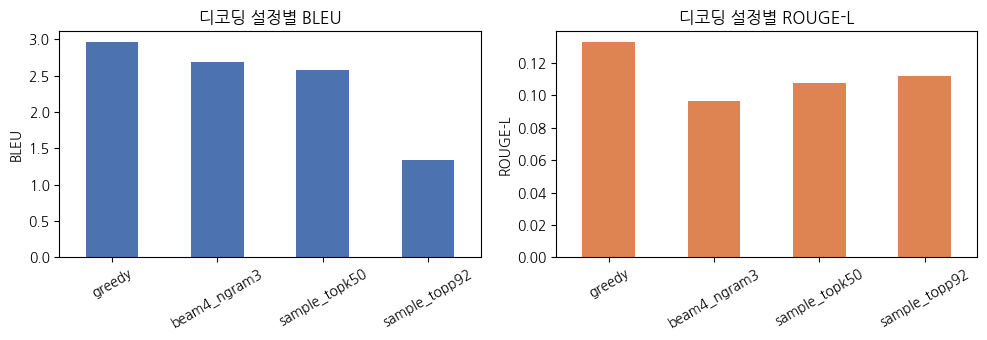

In [35]:
decode_df = pd.DataFrame(decode_results).T  # index: 설정명, columns: BLEU, ROUGE-L

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
decode_df['BLEU'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('디코딩 설정별 BLEU')
axes[0].set_ylabel('BLEU')
axes[0].tick_params(axis='x', rotation=30)

decode_df['ROUGE-L'].plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('디코딩 설정별 ROUGE-L')
axes[1].set_ylabel('ROUGE-L')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 프롬프트 템플릿 서치

In [36]:
PROMPT_TEMPLATES = {
    "training_format": TRAINING_PROMPT_TEMPLATE,
    "explicit_instruction": (
        "다음은 사용자의 질문입니다. 친절하고 정확하게, 사실에 기반해 답변하세요.\n\n"
        "질문: {prompt}\n"
        "답변:"
    ),
    "fewshot_1shot": (
        "### Instruction(명령어):\n대한민국의 수도는 어디인가요?\n\n"
        "### Response(응답): 대한민국의 수도는 서울입니다.\n\n"
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    ),
}

prompt_results = {}
for name, tmpl in PROMPT_TEMPLATES.items():
    preds = generate_texts('/content/output_1_SFT_cleaned', tokenizer, eval_prompts,
                            prompt_template=tmpl, **best_decode_cfg)
    prompt_results[name] = eval_generations(preds, eval_refs)
    print(name, prompt_results[name])

best_prompt_name = max(prompt_results, key=lambda k: prompt_results[k]['ROUGE-L'])
best_prompt_template = PROMPT_TEMPLATES[best_prompt_name]
print(f"\n최적 프롬프트 템플릿: {best_prompt_name}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

training_format {'BLEU': 2.96, 'ROUGE-L': np.float64(0.1327)}


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

explicit_instruction {'BLEU': 1.35, 'ROUGE-L': np.float64(0.082)}


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

fewshot_1shot {'BLEU': 0.96, 'ROUGE-L': np.float64(0.0627)}

최적 프롬프트 템플릿: training_format


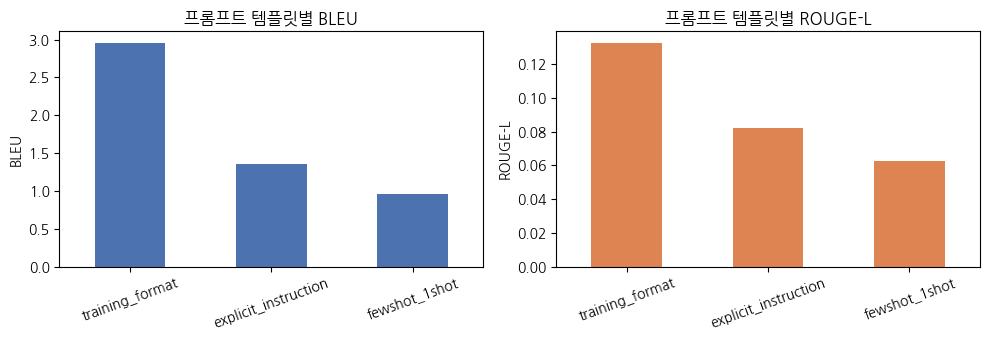

In [37]:
prompt_df = pd.DataFrame(prompt_results).T

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
prompt_df['BLEU'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('프롬프트 템플릿별 BLEU')
axes[0].set_ylabel('BLEU')
axes[0].tick_params(axis='x', rotation=20)

prompt_df['ROUGE-L'].plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('프롬프트 템플릿별 ROUGE-L')
axes[1].set_ylabel('ROUGE-L')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Base KoGPT2 vs 기존 SFT vs 정제 후 SFT — 정량 비교

In [38]:
# 최종 비교는 decoding/프롬프트 고를 때 안 썼던 test로 했다.
test_prompts = [d['prompt'] for d in test_rows]
test_refs    = [d['completion'] for d in test_rows]

preds_base_best      = generate_texts('skt/kogpt2-base-v2', tokenizer, test_prompts,
                                       prompt_template=best_prompt_template, **best_decode_cfg)
preds_sft_orig_best  = generate_texts('/content/output_1_SFT', tokenizer, test_prompts,
                                       prompt_template=best_prompt_template, **best_decode_cfg)
preds_sft_clean_best = generate_texts('/content/output_1_SFT_cleaned', tokenizer, test_prompts,
                                       prompt_template=best_prompt_template, **best_decode_cfg)
preds_sft_clean_noaug_best = generate_texts('/content/output_1_SFT_clean_noaug', tokenizer, test_prompts,
                                             prompt_template=best_prompt_template, **best_decode_cfg)

comparison_summary = pd.DataFrame({
    "Base KoGPT2":       eval_generations(preds_base_best, test_refs),
    "SFT (정제 전)":      eval_generations(preds_sft_orig_best, test_refs),
    "SFT (정제만)":       eval_generations(preds_sft_clean_noaug_best, test_refs),
    "SFT (정제+증강 후)": eval_generations(preds_sft_clean_best, test_refs),
}).T
comparison_summary

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

,BLEU,ROUGE-L
Base KoGPT2,0.00,0.0000
SFT (정제 전),3.09,0.1299
SFT (정제만),3.53,0.1337
SFT (정제+증강 후),2.62,0.1225


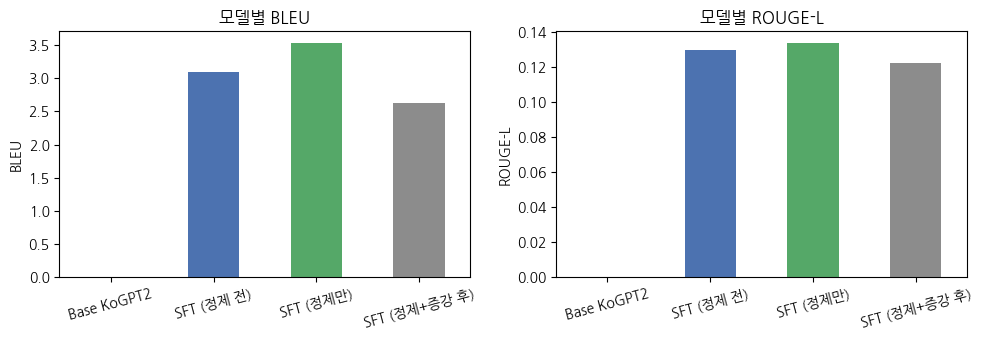

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
comparison_summary['BLEU'].plot(kind='bar', ax=axes[0], color=['#8C8C8C', '#4C72B0', '#55A868'])
axes[0].set_title('모델별 BLEU')
axes[0].set_ylabel('BLEU')
axes[0].tick_params(axis='x', rotation=15)

comparison_summary['ROUGE-L'].plot(kind='bar', ax=axes[1], color=['#8C8C8C', '#4C72B0', '#55A868'])
axes[1].set_title('모델별 ROUGE-L')
axes[1].set_ylabel('ROUGE-L')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### RM을 이용한 SFT 출력 정량 분석

In [40]:
def score_with_rm(texts, prompts, rm_model=model, rm_tokenizer=tokenizer):

    rm_model.eval()
    scores = []
    for p, t in zip(prompts, texts):
        # 빈 문자열 나오면 에러나서 eos_token으로 바꿔줬다
        safe_text = t if t.strip() else rm_tokenizer.eos_token
        full_text = p + safe_text
        ids = rm_tokenizer.encode(full_text, max_length=512, truncation=True, return_tensors='pt').cuda()
        with torch.no_grad():
            s = rm_model(ids).cpu().detach().numpy()[0]
        scores.append(float(s))
    return scores

reward_base            = score_with_rm(preds_base_best, test_prompts)
reward_sft_orig        = score_with_rm(preds_sft_orig_best, test_prompts)
reward_sft_clean_noaug = score_with_rm(preds_sft_clean_noaug_best, test_prompts)
reward_sft_cleaned     = score_with_rm(preds_sft_clean_best, test_prompts)

reward_summary = pd.DataFrame({
    "Base KoGPT2":       [np.mean(reward_base), np.std(reward_base)],
    "SFT (정제 전)":      [np.mean(reward_sft_orig), np.std(reward_sft_orig)],
    "SFT (정제만)":       [np.mean(reward_sft_clean_noaug), np.std(reward_sft_clean_noaug)],
    "SFT (정제+증강 후)": [np.mean(reward_sft_cleaned), np.std(reward_sft_cleaned)],
}, index=["평균 reward", "표준편차"])
reward_summary

,Base KoGPT2,SFT (정제 전),SFT (정제만),SFT (정제+증강 후)
평균 reward,-2.004387,-2.236271,-2.203559,-2.220597
표준편차,0.246106,0.350171,0.351482,0.330608


/tmp/ipykernel_3511/2500264933.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(reward_lists, labels=labels)


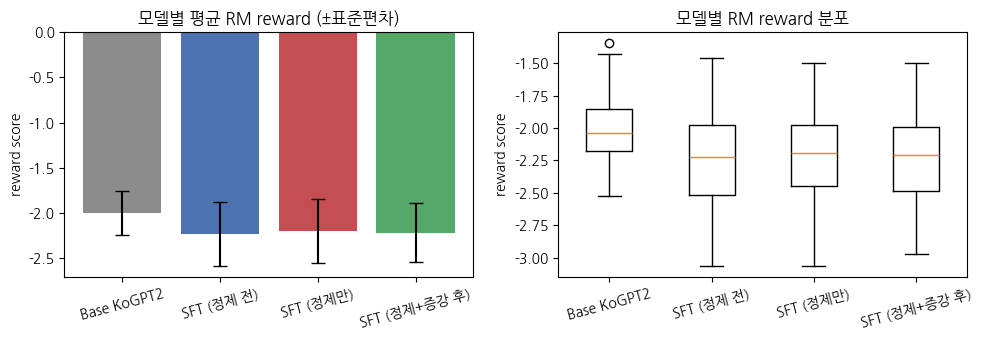

In [41]:
labels = ["Base KoGPT2", "SFT (정제 전)", "SFT (정제만)", "SFT (정제+증강 후)"]
reward_lists = [reward_base, reward_sft_orig, reward_sft_clean_noaug, reward_sft_cleaned]
means = [np.mean(r) for r in reward_lists]
stds  = [np.std(r) for r in reward_lists]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(labels, means, yerr=stds, capsize=5, color=['#8C8C8C', '#4C72B0', '#C44E52', '#55A868'])
axes[0].set_title('모델별 평균 RM reward (±표준편차)')
axes[0].set_ylabel('reward score')
axes[0].tick_params(axis='x', rotation=15)

axes[1].boxplot(reward_lists, labels=labels)
axes[1].set_title('모델별 RM reward 분포')
axes[1].set_ylabel('reward score')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 정성적 비교 샘플

In [42]:
sample_idx = random.sample(range(len(test_prompts)), 5)

rows = []
for i in sample_idx:
    rows.append({
        "prompt": test_prompts[i],
        "base (reward)": f"{preds_base_best[i]}  [{reward_base[i]:.2f}]",
        "SFT 정제전 (reward)": f"{preds_sft_orig_best[i]}  [{reward_sft_orig[i]:.2f}]",
        "SFT 정제만 (reward)": f"{preds_sft_clean_noaug_best[i]}  [{reward_sft_clean_noaug[i]:.2f}]",
        "SFT 정제+증강 (reward)": f"{preds_sft_clean_best[i]}  [{reward_sft_cleaned[i]:.2f}]",
        "정답": test_refs[i],
    })

pd.DataFrame(rows)

,prompt,base (reward),SFT 정제전 (reward),SFT 정제만 (reward),SFT 정제+증강 (reward),정답
0,대한민국 14대 대선은 언제 했어,##############################################...,"'저는 인공지능 언어모델이며, 대한민국 14대 대선은 2012년 6월 3일에 실시되...","'저는 인공지능 언어모델이며, 대한민국 14대 대선은 2012년 4월 16일에 실시...",'대한민국 14대 대선은 1997년 12월 25일에 실시되었습니다. [-1.97],'대한민국 14대 대선은 2002년 12월 19일에 있었습니다.
1,김태영 국방장관이 천안함 침몰 사건의 원인이 어뢰 가능성이 높다고 답변한것은 어디인가?,##############################################...,'김태영 국방장관이 천안함 침몰 사건의 원인이 어뢰 가능성이 높다고 답변한 것은 북...,'김태영 국방장관이 천안함 침몰 사건의 원인이 어뢰 가능성이 높다고 답변한 것은 북...,'김태영 국방장관이 천안함 침몰 사건의 원인이 어뢰 가능성이 높다고 답변한 것은 북...,'김태영 국방장관이 천안함 침몰 사건의 원인이 어뢰 가능성이 높다고 답변한 곳은 국...
2,김영삼이 자유당을 이탈한 후 가입한 정당은?,##############################################...,'김영삼이 자유당을 이탈한 후 가입한 정당은 자유한국당입니다. [-2.71],'자유한국당이 자유한국당을 이탈한 후 가입한 정당은 자유한국당입니다. [-2.49],'자유한국당이 자유한국당을 이탈한 후 가입한 정당은 자유한국당입니다. [-2.49],'통일민주당입니다.
3,이경수가 출연한 방송에는 어떤 것들이 있지,##############################################...,"'저는 인공지능 언어모델로써, 이경수가 출연한 방송에 대한 정보를 가지고 있지 않습...","'저는 인공지능 언어모델로써, 이경수가 출연한 방송에 대한 정보를 가지고 있지 않습...","'제가 알기로는, 이경은수가 출연한 방송에 대한 정보는 제공되지 않았습니다. [-...","'않을까요?\n\n저는 AI 어시스턴트이므로, 이경수의 출연 방송에 대한 정보를 가..."
4,유프 하인케스가 바이에른 뮌헨의 감독을 하면서 몇 번의 리그 우승을 했지,##############################################...,'유프 하인케스가 바이에른 뮌헨의 감독을 하면서 몇 번의 리그 우승을 했는지는 정확...,'유프 하인케스가 바이에른 뮌헨의 감독을 하면서 몇 번의 리그 우승을 했는지에 대한...,"'저는 인공지능 언어모델이며, 유프 하인케스가 바이에른 뮌헨의 감독을 맡은 몇 번의...",'약 7번의 리그 우승을 했습니다.


## RM 적용 전후 비교 (best-of-4)

지금까지는 SFT가 생성한 답변 하나에 RM 점수만 붙여봤는데, 그건 RM을 적용한 게 아니라 채점만 한 거였다.
RM을 실제로 답변 선택에 쓰는 걸 보여주려고, 같은 프롬프트로 답변을 4개 샘플링한 다음 RM 점수가 제일 높은 걸 고르는 방식(best-of-N)을 추가했다.

In [43]:
def generate_candidates(model_path, tokenizer, prompts, prompt_template, n=4, seed=CONFIG["SEED"]):

    set_all_seeds(seed)
    gen_model = AutoModelForCausalLM.from_pretrained(model_path).to(device)
    gen_model.eval()

    all_candidates = []
    for p in prompts:
        text_in = prompt_template.format(prompt=p)
        input_ids = tokenizer.encode(text_in, return_tensors='pt').to(device)
        with torch.no_grad():
            out = gen_model.generate(
                input_ids, max_new_tokens=CONFIG["MAX_NEW_TOKENS"],
                do_sample=True, top_k=0, top_p=0.92, temperature=1.0,
                num_return_sequences=n,
            )
        candidates = [tokenizer.decode(o[input_ids.shape[1]:], skip_special_tokens=True).strip() for o in out]
        all_candidates.append(candidates)

    del gen_model
    torch.cuda.empty_cache()
    return all_candidates


N_CANDIDATES = 4
candidate_groups = generate_candidates('/content/output_1_SFT_cleaned', tokenizer, test_prompts,
                                        TRAINING_PROMPT_TEMPLATE, n=N_CANDIDATES)

first_answers, rm_best_answers = [], []
for prompt, candidates in zip(test_prompts, candidate_groups):
    scores = score_with_rm(candidates, [prompt] * len(candidates))
    best_idx = int(np.argmax(scores))
    first_answers.append(candidates[0])          # RM 없이 그냥 첫 번째로 나온 답
    rm_best_answers.append(candidates[best_idx])  # RM이 제일 높게 준 답

rm_compare = pd.DataFrame({
    "첫 번째 답변 (RM 미적용)":   eval_generations(first_answers, test_refs),
    "RM이 고른 답변 (best-of-4)": eval_generations(rm_best_answers, test_refs),
}).T
rm_compare["RM reward 평균"] = [
    np.mean(score_with_rm(first_answers, test_prompts)),
    np.mean(score_with_rm(rm_best_answers, test_prompts)),
]
rm_compare

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

,BLEU,ROUGE-L,RM reward 평균
첫 번째 답변 (RM 미적용),2.02,0.0974,-2.242407
RM이 고른 답변 (best-of-4),2.26,0.0828,-2.028496


In [44]:
rm_pick_idx = random.sample(range(len(test_prompts)), 5)

rm_pick_rows = []
for i in rm_pick_idx:
    rm_pick_rows.append({
        "prompt": test_prompts[i],
        "첫 번째 답변": first_answers[i],
        "RM이 고른 답변": rm_best_answers[i],
        "같은 답을 골랐나": first_answers[i] == rm_best_answers[i],
        "정답": test_refs[i],
    })

pd.DataFrame(rm_pick_rows)

,prompt,첫 번째 답변,RM이 고른 답변,같은 답을 골랐나,정답
0,대한민국 14대 대선은 언제 했어,'대한민국 14대 대선은 2012년 2월 25일에 치러졌습니다.,"'2021년 2월 17일, 대한민국 13대 대선은 4월 5일에 실시되었습니다.",False,'대한민국 14대 대선은 2002년 12월 19일에 있었습니다.
1,김태영 국방장관이 천안함 침몰 사건의 원인이 어뢰 가능성이 높다고 답변한것은 어디인가?,'김 장관은 천안함 침몰 사건의 원인이 어뢰에 의한 것으로 알려져 있다고 답변을 했...,'김태영 국방장관이 천안함 침몰 사건의 원인이 어뢰 가능성에 있다고 답변한 것은 2...,False,'김태영 국방장관이 천안함 침몰 사건의 원인이 어뢰 가능성이 높다고 답변한 곳은 국...
2,김영삼이 자유당을 이탈한 후 가입한 정당은?,'저는 인공지능 어시스턴트로써 정치적인 민감성을 가지지 않습니다. 그러나 김종인 대...,'저는 인공지능 어시스턴트로써 정치적인 민감성을 가지지 않습니다. 그러나 김종인 대...,True,'통일민주당입니다.
3,이경수가 출연한 방송에는 어떤 것들이 있지,'저는 인공지능 어시스턴트이므로 이씨의 출연한 방송 내용에 대한 정보를 알 수 없습...,"'죄송하지만, 이전 경수에 대한 정보가 제공되지 않아 정확한 답변을 드리기 어렵습니...",False,"'않을까요?\n\n저는 AI 어시스턴트이므로, 이경수의 출연 방송에 대한 정보를 가..."
4,유프 하인케스가 바이에른 뮌헨의 감독을 하면서 몇 번의 리그 우승을 했지,'요크 나이트입니다.,"'요즘의 축구 선수들의 챔피언스리그 우승을 평가하는 기준은 ""슈퍼리그 우승""입니다....",False,'약 7번의 리그 우승을 했습니다.


## (추가 실험) Foundation Model 교체 — ko-gpt-trinity-1.2B (LoRA)

kogpt2 대신 더 큰 모델로 바꿔서 해보고 싶어서 시도해봤고 그대로 학습시키면 터질 것 같아서 LoRA를 썼다.

### 모델 / 토크나이저 로드

In [45]:
large_tokenizer = AutoTokenizer.from_pretrained(CONFIG["LARGE_MODEL_NAME"])
if large_tokenizer.pad_token is None:
    large_tokenizer.pad_token = large_tokenizer.eos_token
large_tokenizer.model_max_length = 512

train_dataset_large = SFT_dataset(
    data_path_1_SFT=train_raw_path,
    tokenizer=large_tokenizer,
)
data_collator_large = DataCollatorForSupervisedDataset(tokenizer=large_tokenizer)

base_large_model = AutoModelForCausalLM.from_pretrained(CONFIG["LARGE_MODEL_NAME"])
n_params = sum(p.numel() for p in base_large_model.parameters())
print(f"{CONFIG['LARGE_MODEL_NAME']} 전체 파라미터 수: {n_params/1e9:.2f}B")

config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/109 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.68GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


skt/ko-gpt-trinity-1.2B-v0.5 전체 파라미터 수: 1.16B


### LoRA 적용 — 경량화 파인튜닝

다 학습시키기엔 너무 커서 c_attn 부분만 LoRA로 학습시켰다.

In [46]:
lora_config = LoraConfig(
    r=CONFIG["LORA_R"],
    lora_alpha=CONFIG["LORA_ALPHA"],
    lora_dropout=CONFIG["LORA_DROPOUT"],
    target_modules=CONFIG["LORA_TARGET_MODULES"],
    task_type=TaskType.CAUSAL_LM,
)

probe_model = get_peft_model(base_large_model, lora_config)
probe_model.print_trainable_parameters()

trainable params: 1,474,560 || all params: 1,164,030,720 || trainable%: 0.1267


/usr/local/lib/python3.13/dist-packages/peft/tuners/lora/layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


### OOM 방지 training argument 탐색

터질까봐 batch size랑 설정 몇 개 바꿔가면서 돌려봤다.

In [47]:
OOM_CONFIGS = [
    dict(per_device_train_batch_size=8, gradient_accumulation_steps=1, fp16=True, gradient_checkpointing=False),
    dict(per_device_train_batch_size=4, gradient_accumulation_steps=2, fp16=True, gradient_checkpointing=False),
    dict(per_device_train_batch_size=2, gradient_accumulation_steps=4, fp16=True, gradient_checkpointing=True),
    dict(per_device_train_batch_size=1, gradient_accumulation_steps=8, fp16=True, gradient_checkpointing=True),
]

chosen_large_cfg = None
for cfg in OOM_CONFIGS:
    try:
        probe_args = transformers.TrainingArguments(
            output_dir="/content/test_large_probe",
            max_steps=5,
            learning_rate=CONFIG["LARGE_LR"],
            seed=CONFIG["SEED"],
            logging_steps=100,
            prediction_loss_only=True,
            **cfg,
        )
        if cfg.get("gradient_checkpointing"):
            probe_model.gradient_checkpointing_enable()
            probe_model.enable_input_require_grads()
        probe_trainer = transformers.Trainer(
            model=probe_model, args=probe_args,
            data_collator=data_collator_large, train_dataset=train_dataset_large,
        )
        probe_trainer.train()
        chosen_large_cfg = cfg
        print("OK:", cfg)
        break
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("OOM:", cfg, "-> 다음 설정 시도")
            torch.cuda.empty_cache()
            continue
        raise

if chosen_large_cfg is None:
    chosen_large_cfg = OOM_CONFIGS[-1]

del probe_model, base_large_model
torch.cuda.empty_cache()
print("\n최종 선택된 설정:", chosen_large_cfg)

Step,Training Loss


OK: {'per_device_train_batch_size': 8, 'gradient_accumulation_steps': 1, 'fp16': True, 'gradient_checkpointing': False}

최종 선택된 설정: {'per_device_train_batch_size': 8, 'gradient_accumulation_steps': 1, 'fp16': True, 'gradient_checkpointing': False}


### 선택된 설정으로 SFT 재학습

In [48]:
set_all_seeds()
large_model = AutoModelForCausalLM.from_pretrained(CONFIG["LARGE_MODEL_NAME"])
large_model = get_peft_model(large_model, lora_config)
large_model.print_trainable_parameters()

if chosen_large_cfg.get("gradient_checkpointing"):
    large_model.gradient_checkpointing_enable()
    large_model.enable_input_require_grads()

training_args_large = transformers.TrainingArguments(
    output_dir="/content/test_large",
    num_train_epochs=CONFIG["LARGE_EPOCHS"],
    learning_rate=CONFIG["LARGE_LR"],
    warmup_steps=CONFIG["WARMUP_STEPS"],
    seed=CONFIG["SEED"],
    prediction_loss_only=True,
    **chosen_large_cfg,
)
trainer_large = transformers.Trainer(
    model=large_model,
    args=training_args_large,
    data_collator=data_collator_large,
    train_dataset=train_dataset_large,
)
trainer_large.train()
large_model.save_pretrained('/content/output_1_SFT_large')  # LoRA 어댑터만 저장되어 용량이 작음
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 1,474,560 || all params: 1,164,030,720 || trainable%: 0.1267


Step,Training Loss
500,2.009003
1000,1.606522
1500,1.546227
2000,1.466655
2500,1.491341
3000,1.477980
3500,1.427827
4000,1.444695


### 기존 모델들과 정량 비교

이전에 고른 디코딩/프롬프트 설정을 그대로 썼다.

In [49]:
base_for_gen = AutoModelForCausalLM.from_pretrained(CONFIG["LARGE_MODEL_NAME"])
large_model_for_gen = PeftModel.from_pretrained(base_for_gen, '/content/output_1_SFT_large')
large_model_for_gen = large_model_for_gen.merge_and_unload().to(device)  # LoRA 가중치를 base에 합쳐 일반 모델처럼 사용

preds_large_best = generate_texts(large_model_for_gen, large_tokenizer, test_prompts,
                                   is_path=False, prompt_template=best_prompt_template, **best_decode_cfg)

comparison_summary_large = comparison_summary.copy()
comparison_summary_large.loc["SFT (1.2B + LoRA)"] = eval_generations(preds_large_best, test_refs)
comparison_summary_large

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,BLEU,ROUGE-L
Base KoGPT2,0.00,0.0000
SFT (정제 전),3.09,0.1299
SFT (정제만),3.53,0.1337
SFT (정제+증강 후),2.62,0.1225
SFT (1.2B + LoRA),0.00,0.0000


#### 1.2B가 BLEU/ROUGE 0인 이유 확인

숫자만 보면 이유를 알 수 없어서, 실제로 뭘 생성했는지 몇 개 찍어본다.

In [50]:
for q, a in zip(test_prompts[:5], preds_large_best[:5]):
    print("질문:", q)
    print("답변:", repr(a))
    print()

질문: 이러면 안되는데
답변: "'..."

질문: 천연으로 염색하고 싶은데 지속이 꽤 되나요?
답변: "'.."

질문: 흥선대원군과 같이 암살을 공모한 사람은?
답변: "'.."

질문: 김영삼이 자유당을 이탈한 후 가입한 정당은?
답변: "'.."

질문: 제로 페이 가능한가요?
답변: "'.."



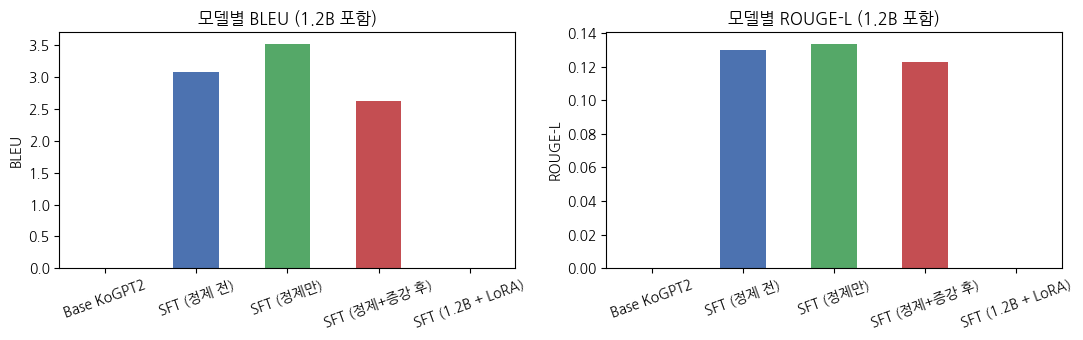

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
colors = ['#8C8C8C', '#4C72B0', '#55A868', '#C44E52']
comparison_summary_large['BLEU'].plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('모델별 BLEU (1.2B 포함)')
axes[0].set_ylabel('BLEU')
axes[0].tick_params(axis='x', rotation=20)

comparison_summary_large['ROUGE-L'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('모델별 ROUGE-L (1.2B 포함)')
axes[1].set_ylabel('ROUGE-L')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### RM reward 비교 (1.2B 포함)

In [52]:
reward_large = score_with_rm(preds_large_best, test_prompts)

reward_summary_large = reward_summary.copy()
reward_summary_large["SFT (1.2B + LoRA)"] = [np.mean(reward_large), np.std(reward_large)]
reward_summary_large

,Base KoGPT2,SFT (정제 전),SFT (정제만),SFT (정제+증강 후),SFT (1.2B + LoRA)
평균 reward,-2.004387,-2.236271,-2.203559,-2.220597,-2.457012
표준편차,0.246106,0.350171,0.351482,0.330608,0.397434


## 결론

| 모델 | BLEU | ROUGE-L | RM reward |
|---|---:|---:|---:|
| Base KoGPT2 | 0.00 | 0.0000 | -2.004 |
| SFT (정제 전) | 3.09 | 0.1299 | -2.236 |
| SFT (정제만) | **3.53** | **0.1337** | -2.204 |
| SFT (정제+증강 후) | 2.62 | 0.1225 | -2.221 |
| SFT (1.2B + LoRA) | 0.00 | 0.0000 | -2.457 |

- 정제는 도움이 됐는데 증강은 오히려 방해가 됐다. 정제만 한 게 정제 전보다 점수가 더 좋고, 거기에 증강까지 넣으면 오히려 떨어진다. 모음조화 버그를 고치고 나서도 이 결과라, 증강 자체가 문제인 것 같다.
- 1.2B+LoRA는 사실상 답을 못 만들었다. epoch을 3으로 늘려도 답변이 "'...'"처럼 문장부호만 나왔는데, 덜 배워서가 아니라 뭔가 다른게 잘못된 것 같다..
- RM으로 답 골라보기(best-of-4): 5개 중 4개는 첫 번째 답이랑 다른 걸 골랐다.그리고 BLEU는 올랐는데 ROUGE-L은 떨어져서 애매하다.
- RM 점수 자체가 좀 이상하다. Base는 답을 아예 못 만드는데("#####"만 반복) RM reward는 오히려 제일 높게 나온다.

## 회고
이번 프로젝트가 Going Deeper 프로젝트중에 size가 큰 편에 속하는 프로젝트였던것 같은데, 성능을 높이지 못한게 아쉽다.